In [26]:
import os
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from pathlib import Path
import random
import shutil
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, balanced_accuracy_score

In [5]:
#small review
dataset_path = 'data/processed_combine_asl_dataset'

classes = sorted(os.listdir(dataset_path))
print(f"Класів (літер/цифр): {len(classes)}")
print(f"Класи: {classes}")

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(cls_path))
    print(f'  {cls}: {count} зображень')

Класів (літер/цифр): 36
Класи: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
  0: 62 зображень
  1: 113 зображень
  2: 69 зображень
  3: 94 зображень
  4: 94 зображень
  5: 90 зображень
  6: 72 зображень
  7: 90 зображень
  8: 81 зображень
  9: 95 зображень
  a: 3758 зображень
  b: 3369 зображень
  c: 2310 зображень
  d: 4968 зображень
  e: 3961 зображень
  f: 5055 зображень
  g: 5290 зображень
  h: 5203 зображень
  i: 4916 зображень
  j: 2658 зображень
  k: 5414 зображень
  l: 5524 зображень
  m: 1887 зображень
  n: 2281 зображень
  o: 3947 зображень
  p: 3620 зображень
  q: 3726 зображень
  r: 5272 зображень
  s: 4425 зображень
  t: 2202 зображень
  u: 4406 зображень
  v: 5116 зображень
  w: 3769 зображень
  x: 4500 зображень
  y: 4524 зображень
  z: 2459 зображень


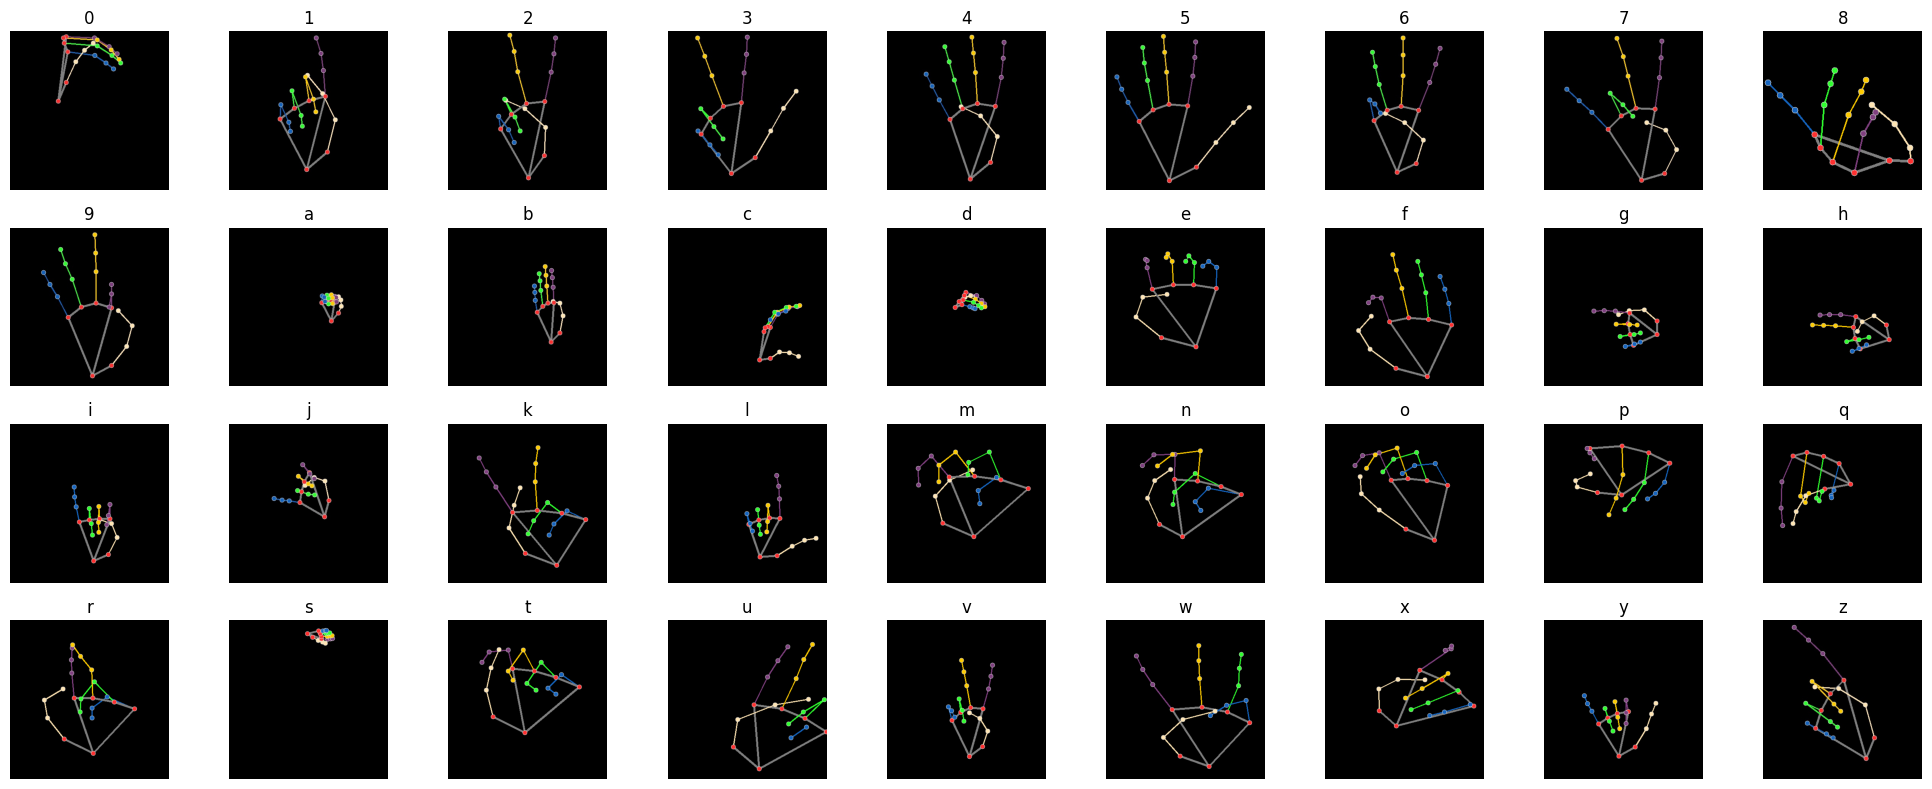

In [6]:
fig, axes = plt.subplots(4, 9, figsize=(20, 8))
for i, cls in enumerate(classes[:]):
    cls_path = os.path.join(dataset_path, cls)
    img_path = os.path.join(cls_path, os.listdir(cls_path)[0])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax = axes[i // 9][i % 9]
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')

plt.tight_layout()
plt.savefig('png/dataset_preview.png')
plt.show()

In [9]:
#split train/test
SRC = Path(r'data/processed_combine_asl_dataset')
DEST = Path('data/dataset_split')
SEED = 42

def n_test(n):
    return max(10, min(20, round(0.15 * n)))

random.seed(SEED)

exts = {".jpg", ".jpeg", ".png"}

trainval_root = DEST / "trainval"
test_root = DEST / "test"
trainval_root.mkdir(parents=True, exist_ok=True)
test_root.mkdir(parents=True, exist_ok=True)

for class_dir in sorted([p for p in SRC.iterdir() if p.is_dir()]):
    files = [p for p in class_dir.iterdir() if p.suffix.lower() in exts]
    random.shuffle(files)

    k = min(n_test(len(files)), len(files) - 1) 
    test_files = files[:k]
    train_files = files[k:]

    (trainval_root / class_dir.name).mkdir(parents=True, exist_ok=True)
    (test_root / class_dir.name).mkdir(parents=True, exist_ok=True)

    for f in test_files:
        shutil.copy2(f, test_root / class_dir.name / f.name)

    for f in train_files:
        shutil.copy2(f, trainval_root / class_dir.name / f.name)

print('Done. Train/Val data in:', trainval_root)
print('Done. Test data in:', test_root)

Done. Train/Val data in: data\dataset_split\trainval
Done. Test data in: data\dataset_split\test


In [11]:
#first draft try
DATASET_PATH = 'data/dataset_split/trainval'
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255, #[0, 1]
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1 
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='training',
    color_mode='rgb'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    subset='validation',
    color_mode='rgb'
)

num_classes = len(train_data.class_indices)
print(f'Послідовність: {train_data.class_indices}')

Found 83829 images belonging to 36 classes.
Found 20941 images belonging to 36 classes.
Послідовність: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'a': 10, 'b': 11, 'c': 12, 'd': 13, 'e': 14, 'f': 15, 'g': 16, 'h': 17, 'i': 18, 'j': 19, 'k': 20, 'l': 21, 'm': 22, 'n': 23, 'o': 24, 'p': 25, 'q': 26, 'r': 27, 's': 28, 't': 29, 'u': 30, 'v': 31, 'w': 32, 'x': 33, 'y': 34, 'z': 35}


In [12]:
#transfer learning on MobileNetV2, ImageNet weights
MobileNetV2 = tf.keras.applications.MobileNetV2
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze layars

#add our layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')#classification layer
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

#5h
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True), #stop if plato 5 epochs
        tf.keras.callbacks.ModelCheckpoint('model/asl_cnn_1.keras', save_best_only=True) #save best weights
    ]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,172 (9.90 MB)

 Trainable params: 337,188 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 2707s 1s/step - accuracy: 0.7743 - loss: 0.7442 - val_accuracy: 0.8381 - val_loss: 0.5585
Epoch 2/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1579s 603ms/step - accuracy: 0.8527 - loss: 0.4753 - val_accuracy: 0.8443 - val_loss: 0.5572
Epoch 3/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1128s 430ms/step - accuracy: 0.8678 - loss: 0.4250 - val_accuracy: 0.8492 - val_loss: 0.5491
Epoch 4/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1051s 388ms/step - accuracy: 0.8768 - loss: 0.3949 - val_accuracy: 0.8646 - val_loss: 0.5309
Epoch 5/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 731s 279ms/step - accuracy: 0.8824 - loss: 0.3779 - val_accuracy: 0.8664 - val_loss: 0.5360
Epoch 6/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 673s 257ms/step - accuracy: 0.8873 - loss: 0.3628 - val_accuracy: 0.8626 - val_loss: 0.5199
Epoch 7/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 652s 249ms/step - accuracy: 0.8912 - loss: 0.3475 - val_accuracy: 0.8565 - val_loss: 0.5458
Epoch 8/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 681s 260ms/step - a

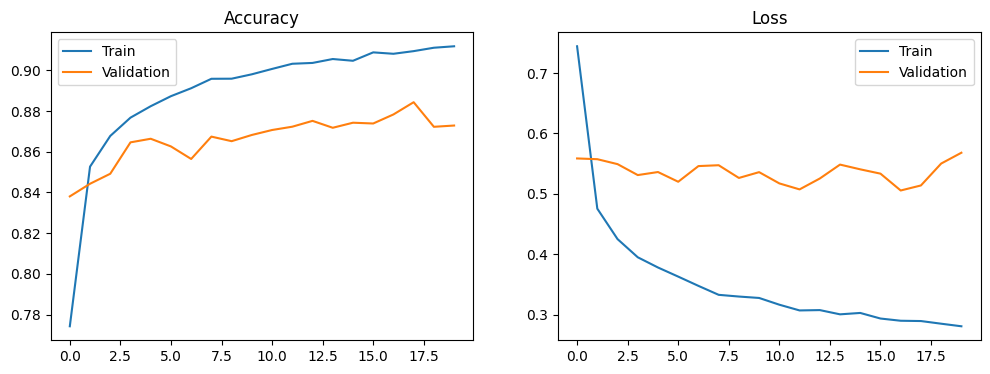

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.savefig('png/training_history_1.png')
plt.show()

In [14]:
#check what model was chosen
best_model = models.load_model('model/asl_cnn_1.keras')
best_model.evaluate(val_data, verbose=0)

[0.513119101524353, 0.8776085376739502]

In [15]:
#different criterion for best 
best_epoch_acc = int(np.argmax(history.history["val_accuracy"])) +1
best_val_acc = float(np.max(history.history["val_accuracy"]))
best_epoch_loss = int(np.argmin(history.history["val_loss"])) + 1
best_val_loss = float(np.min(history.history["val_loss"]))

print('Best by val_accuracy: epoch', best_epoch_acc, 'val_acc =', best_val_acc)
print('Best by val_loss:epoch', best_epoch_loss, 'val_loss =', best_val_loss)

Best by val_accuracy: epoch 18 val_acc = 0.8843417167663574
Best by val_loss:epoch 17 val_loss = 0.5054185390472412


In [16]:
print(len(base_model.layers))

154


In [17]:
history.history

{'accuracy': [0.7742547392845154,
  0.852676272392273,
  0.8677664995193481,
  0.8767610192298889,
  0.8823795914649963,
  0.887306272983551,
  0.8912070989608765,
  0.895847499370575,
  0.89589524269104,
  0.8980543613433838,
  0.9006906747817993,
  0.9032315611839294,
  0.903637170791626,
  0.9055577516555786,
  0.9046988487243652,
  0.9088262915611267,
  0.908134400844574,
  0.9094346761703491,
  0.9111047387123108,
  0.9118204712867737],
 'loss': [0.7441705465316772,
  0.4753253161907196,
  0.42495739459991455,
  0.3948556184768677,
  0.37792035937309265,
  0.36283427476882935,
  0.34749850630760193,
  0.33267712593078613,
  0.3298448920249939,
  0.3274933099746704,
  0.3163345754146576,
  0.3068467080593109,
  0.3074135482311249,
  0.30039089918136597,
  0.3026818335056305,
  0.2934454679489136,
  0.28977200388908386,
  0.2892799377441406,
  0.284877210855484,
  0.28061628341674805],
 'val_accuracy': [0.8380688428878784,
  0.8442767858505249,
  0.8491953611373901,
  0.864619672298

In [18]:
history.params

{'verbose': 'auto', 'epochs': 20, 'steps': 2620}

In [19]:
print(val_data.shuffle)

True


              precision    recall  f1-score   support

           0       1.00      0.20      0.33        10
           1       1.00      0.47      0.64        19
           2       0.45      0.45      0.45        11
           3       1.00      1.00      1.00        16
           4       1.00      0.75      0.86        16
           5       1.00      1.00      1.00        15
           6       1.00      0.25      0.40        12
           7       0.92      0.73      0.81        15
           8       0.83      0.38      0.53        13
           9       0.74      0.88      0.80        16
           a       0.88      0.98      0.93       747
           b       0.97      0.95      0.96       669
           c       0.94      0.98      0.96       458
           d       0.86      0.94      0.90       989
           e       0.83      0.92      0.88       788
           f       0.96      0.99      0.97      1007
           g       0.91      0.97      0.94      1054
           h       0.96    

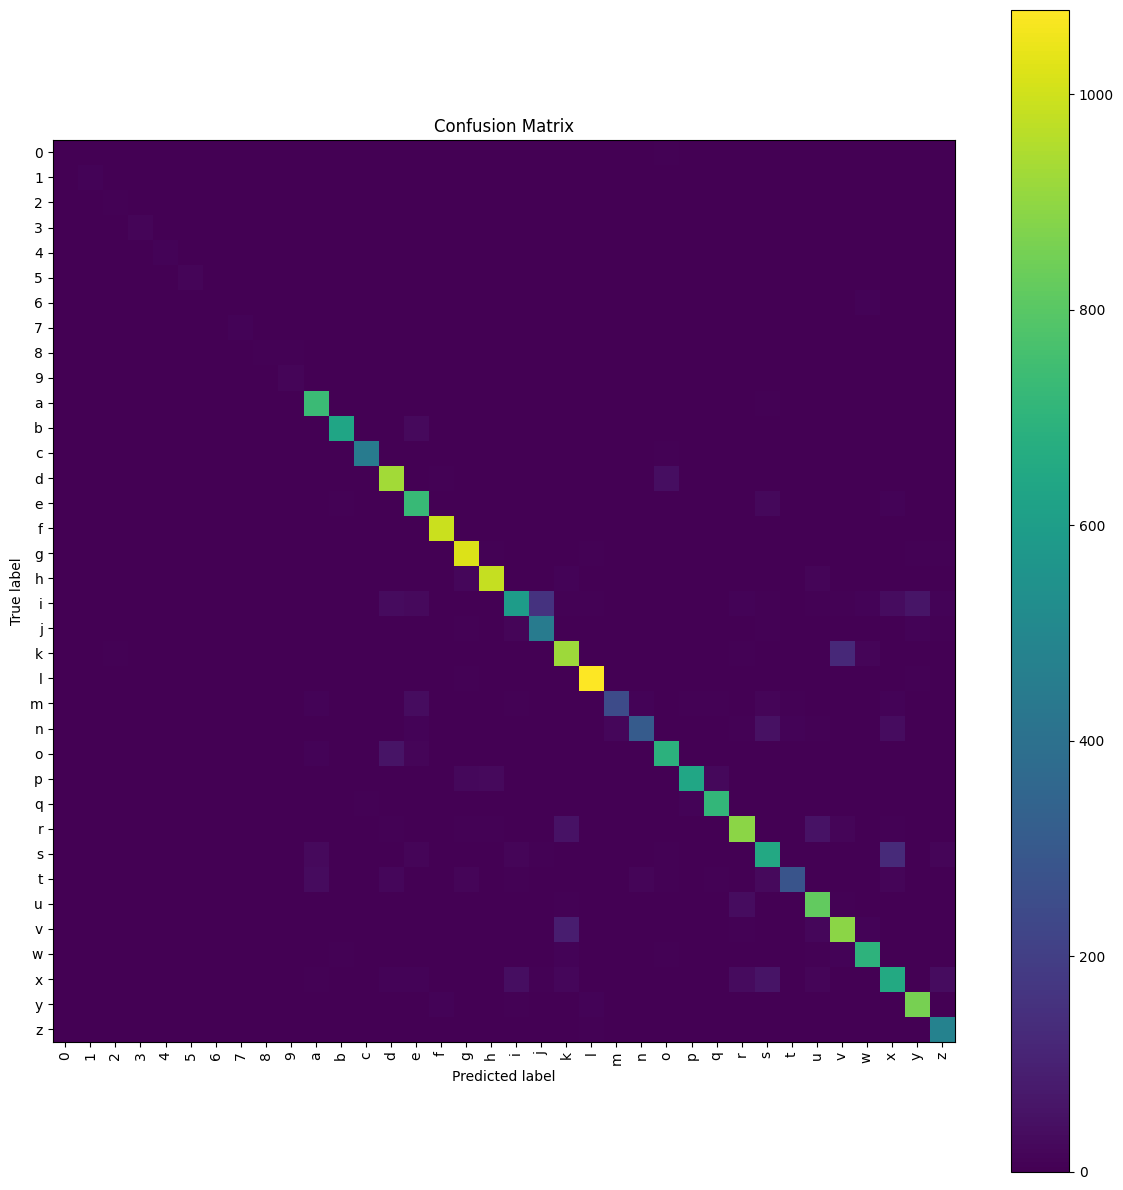

In [20]:
val_data.reset()
y_true = []
y_pred = []
steps = len(val_data) 

for _ in range(steps):
    x_batch, y_batch = next(val_data)
    proba = best_model.predict(x_batch, verbose=0)
    pred = np.argmax(proba, axis=1)
    y_pred.extend(pred.tolist())

    if y_batch.ndim == 2:
        true = np.argmax(y_batch, axis=1)
    else:
        true = y_batch.astype(int)
    y_true.extend(true.tolist())

# right order
idx_to_class = {v: k for k, v in val_data.class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(12, 12))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=90)
plt.yticks(ticks, class_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('png/confusion_matrix_1.png', dpi=200)
plt.show()

In [22]:
TEST_PATH = 'data/dataset_split/test'
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255)

test_data = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

Found 650 images belonging to 36 classes.


In [23]:
test_loss, test_acc = best_model.evaluate(test_data, verbose=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 477ms/step - accuracy: 0.8031 - loss: 0.7456


In [25]:
print(test_data.shuffle)

False


In [27]:
test_data.reset()
proba = best_model.predict(test_data, verbose=0)
y_pred = np.argmax(proba, axis=1)
y_true = test_data.classes

macro_f1 = f1_score(y_true, y_pred, average="macro")
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"TEST macro F1: {macro_f1:.4f}")
print(f"TEST balanced accuracy: {bal_acc:.4f}")

TEST macro F1: 0.7693
TEST balanced accuracy: 0.7714


In [28]:
idx_to_class = {v: k for k, v in test_data.class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           0       1.00      0.60      0.75        10
           1       1.00      0.35      0.52        17
           2       1.00      0.20      0.33        10
           3       1.00      0.86      0.92        14
           4       1.00      0.57      0.73        14
           5       0.90      0.64      0.75        14
           6       0.00      0.00      0.00        11
           7       0.80      0.57      0.67        14
           8       0.71      0.42      0.53        12
           9       0.75      0.86      0.80        14
           a       1.00      0.85      0.92        20
           b       1.00      0.90      0.95        20
           c       1.00      0.95      0.97        20
           d       0.82      0.90      0.86        20
           e       0.57      1.00      0.73        20
           f       0.61      0.95      0.75        20
           g       0.90      0.95      0.93        20
           h       1.00    

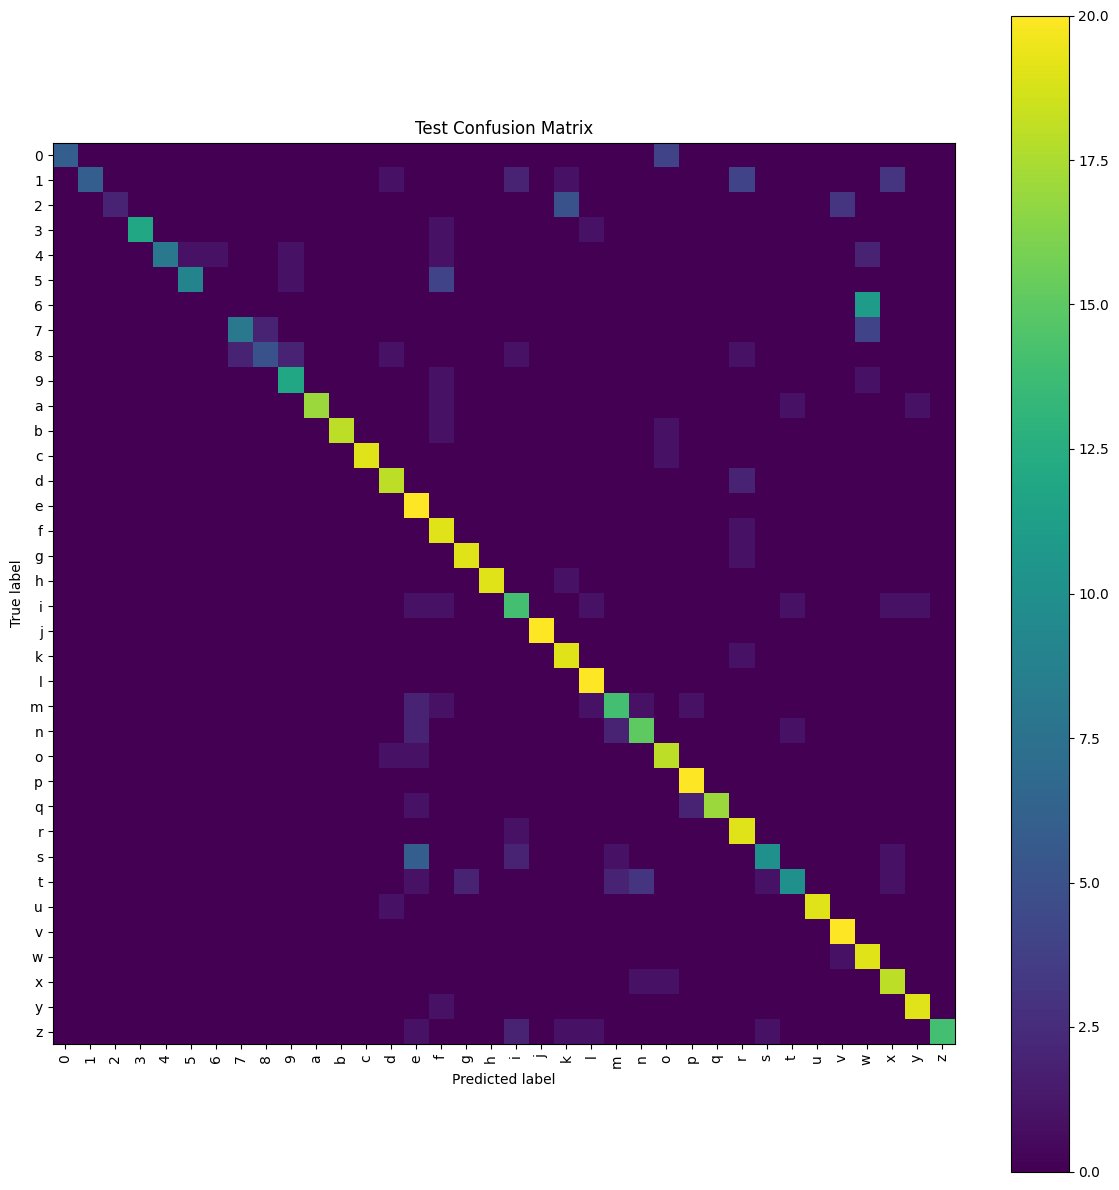

In [29]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

plt.figure(figsize=(12, 12))
plt.imshow(cm, interpolation="nearest")
plt.title("Test Confusion Matrix")
plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=90)
plt.yticks(ticks, class_names)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("png/test_confusion_matrix_1.png", dpi=200)
plt.show()

In [30]:
digit_ids = [test_data.class_indices[str(d)] for d in range(10)]
mask = np.isin(y_true, digit_ids)

digits_macro_f1 = f1_score(np.array(y_true)[mask], np.array(y_pred)[mask], average="macro")
digits_bal_acc  = balanced_accuracy_score(np.array(y_true)[mask], np.array(y_pred)[mask])

print(f"Numbers macro F1: {digits_macro_f1:.4f}")
print(f"Numbers balanced accuracy: {digits_bal_acc:.4f}")

Numbers macro F1: 0.2999
Numbers balanced accuracy: 0.5070


C:\Users\Admin\PycharmProjects\ASL-recognition\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


(((

In [32]:
#second try after some conclusions
DATASET_PATH = 'data/dataset_split/trainval'
IMG_SIZE = (160, 160)# little increase
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

#separate val and train datagenerator to make validation more stable
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,#change rescale [0, 1] --> [-1, 1]
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)
train_data = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed = SEED,
    subset='training',
    color_mode='rgb',
    class_mode = 'categorical'#one-hot
)

val_data = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed = SEED,
    subset='validation',
    color_mode='rgb',
    shuffle=False,
    class_mode = 'categorical'
)

num_classes = len(train_data.class_indices)
print(f"Відповідність: {train_data.class_indices}")

Found 83829 images belonging to 36 classes.
Found 20941 images belonging to 36 classes.
Відповідність: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'a': 10, 'b': 11, 'c': 12, 'd': 13, 'e': 14, 'f': 15, 'g': 16, 'h': 17, 'i': 18, 'j': 19, 'k': 20, 'l': 21, 'm': 22, 'n': 23, 'o': 24, 'p': 25, 'q': 26, 'r': 27, 's': 28, 't': 29, 'u': 30, 'v': 31, 'w': 32, 'x': 33, 'y': 34, 'z': 35}


In [33]:
MobileNetV2 = tf.keras.applications.MobileNetV2
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),#256 --> 128
    layers.Dropout(0.4),#0.3 --> 0.4
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),#запобігає надмірній впевненості в прогнозах, робить вектор класифікації менш екстремальним, запобігає перенавчанню
     #в першому тренуванні першої версії сильно стибав лос(набагато сильніше ніж в цьому ноутбуці), можливо через занадто впевнені неправильні передбачення
    metrics=['accuracy']
)

model.summary()

#збільшується вартість помилки на класах цифр
#їх набагато менше, спроба збалансувати
classes = np.unique(train_data.classes)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_data.classes
)
class_weight = dict(zip(classes, weights))
class_weight = {c: float(np.sqrt(w)) for c, w in class_weight.items()}#трохи пом'якшили ваги коренем

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,596 (9.26 MB)

 Trainable params: 168,612 (658.64 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
#3h
history_2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    class_weight = class_weight,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', mode = 'max', patience = 5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('model/asl_cnn_2.keras', monitor='val_accuracy', mode = 'max', save_best_only=True)#change criterion for evaluation
    ]
)

Epoch 1/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1102s 419ms/step - accuracy: 0.6764 - loss: 1.5416 - val_accuracy: 0.8237 - val_loss: 1.3061
Epoch 2/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1193s 455ms/step - accuracy: 0.7889 - loss: 1.2665 - val_accuracy: 0.8215 - val_loss: 1.2760
Epoch 3/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1159s 442ms/step - accuracy: 0.8155 - loss: 1.2081 - val_accuracy: 0.8642 - val_loss: 1.1888
Epoch 4/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1302s 497ms/step - accuracy: 0.8240 - loss: 1.1819 - val_accuracy: 0.8533 - val_loss: 1.2004
Epoch 5/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1591s 607ms/step - accuracy: 0.8366 - loss: 1.1560 - val_accuracy: 0.8560 - val_loss: 1.2046
Epoch 6/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1580s 603ms/step - accuracy: 0.8407 - loss: 1.1437 - val_accuracy: 0.8574 - val_loss: 1.1826
Epoch 7/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1901s 725ms/step - accuracy: 0.8460 - loss: 1.1301 - val_accuracy: 0.8545 - val_loss: 1.1994
Epoch 8/20
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1106s 406ms/s

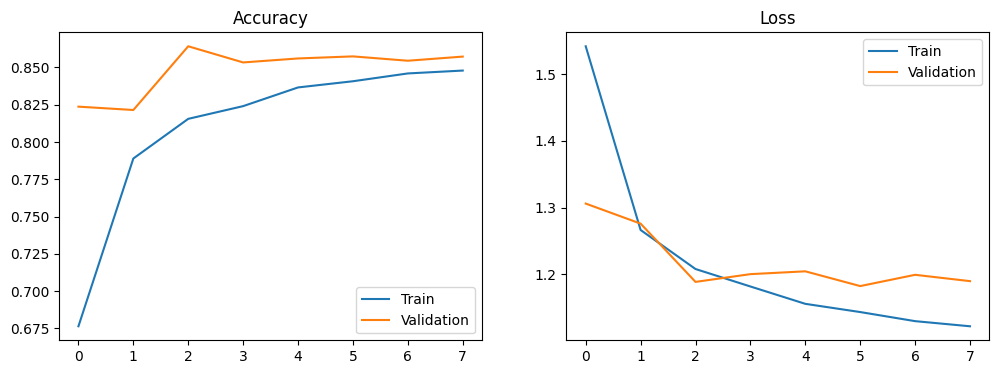

In [35]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2.history['accuracy'], label='Train')
plt.plot(history_2.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2.history['loss'], label='Train')
plt.plot(history_2.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.savefig('png/training_history_2.png')
plt.show()

In [36]:
#fine-tuning stage unfreeze 20 trainable layers and train them on our data with slower learning rate
base_model.trainable = True

fine_tune_layers = 20
for layer in base_model.layers[:-fine_tune_layers]:
    layer.trainable = False
    
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

classes = np.unique(train_data.classes)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_data.classes
)
class_weight = dict(zip(classes, weights))
class_weight = {c: float(np.sqrt(w)) for c, w in class_weight.items()}

#3h
history_2_2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight = class_weight,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', mode = 'max', patience = 3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('model/asl_cnn_2_2.keras', monitor='val_accuracy', mode = 'max', save_best_only=True)
    ]
)

Epoch 1/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1149s 436ms/step - accuracy: 0.7122 - loss: 1.4763 - val_accuracy: 0.8181 - val_loss: 1.3139
Epoch 2/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1069s 408ms/step - accuracy: 0.8343 - loss: 1.1945 - val_accuracy: 0.8546 - val_loss: 1.2046
Epoch 3/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1082s 413ms/step - accuracy: 0.8669 - loss: 1.1118 - val_accuracy: 0.8806 - val_loss: 1.1229
Epoch 4/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1087s 415ms/step - accuracy: 0.8862 - loss: 1.0567 - val_accuracy: 0.8947 - val_loss: 1.0800
Epoch 5/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1071s 409ms/step - accuracy: 0.8984 - loss: 1.0238 - val_accuracy: 0.9041 - val_loss: 1.0486
Epoch 6/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1076s 411ms/step - accuracy: 0.9090 - loss: 0.9943 - val_accuracy: 0.9084 - val_loss: 1.0363
Epoch 7/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1084s 414ms/step - accuracy: 0.9161 - loss: 0.9720 - val_accuracy: 0.9120 - val_loss: 1.0203
Epoch 8/10
2620/2620 ━━━━━━━━━━━━━━━━━━━━ 1084s 414ms/s

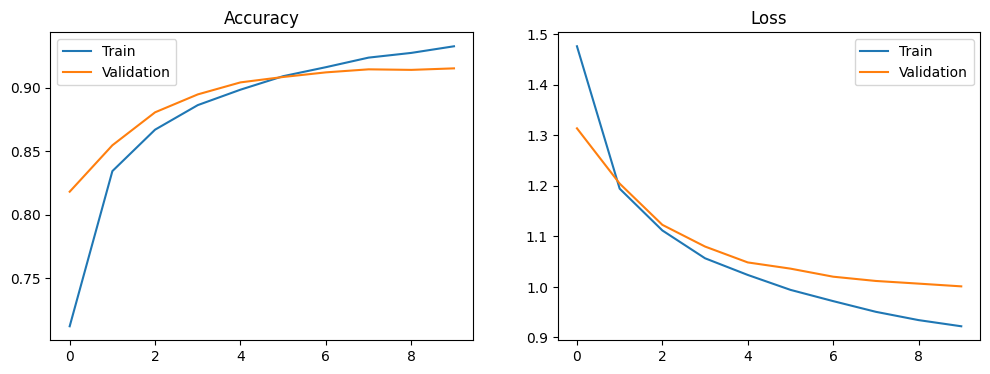

In [37]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_2_2.history['accuracy'], label='Train')
plt.plot(history_2_2.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_2_2.history['loss'], label='Train')
plt.plot(history_2_2.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.savefig('png/training_history_2_2.png')
plt.show()

In [38]:
best_model_2_2 = models.load_model('model/asl_cnn_2_2.keras')
best_model_2_2.evaluate(val_data, verbose=0)

[1.0011799335479736, 0.9151425361633301]

              precision    recall  f1-score   support

           0       1.00      0.30      0.46        10
           1       0.90      1.00      0.95        19
           2       0.18      0.82      0.30        11
           3       1.00      1.00      1.00        16
           4       1.00      0.94      0.97        16
           5       1.00      1.00      1.00        15
           6       1.00      0.67      0.80        12
           7       1.00      1.00      1.00        15
           8       1.00      0.92      0.96        13
           9       1.00      1.00      1.00        16
           a       0.86      0.99      0.92       747
           b       0.99      0.95      0.97       669
           c       0.91      1.00      0.95       458
           d       0.96      0.93      0.95       989
           e       0.82      0.94      0.88       788
           f       0.98      0.99      0.98      1007
           g       0.97      0.97      0.97      1054
           h       0.96    

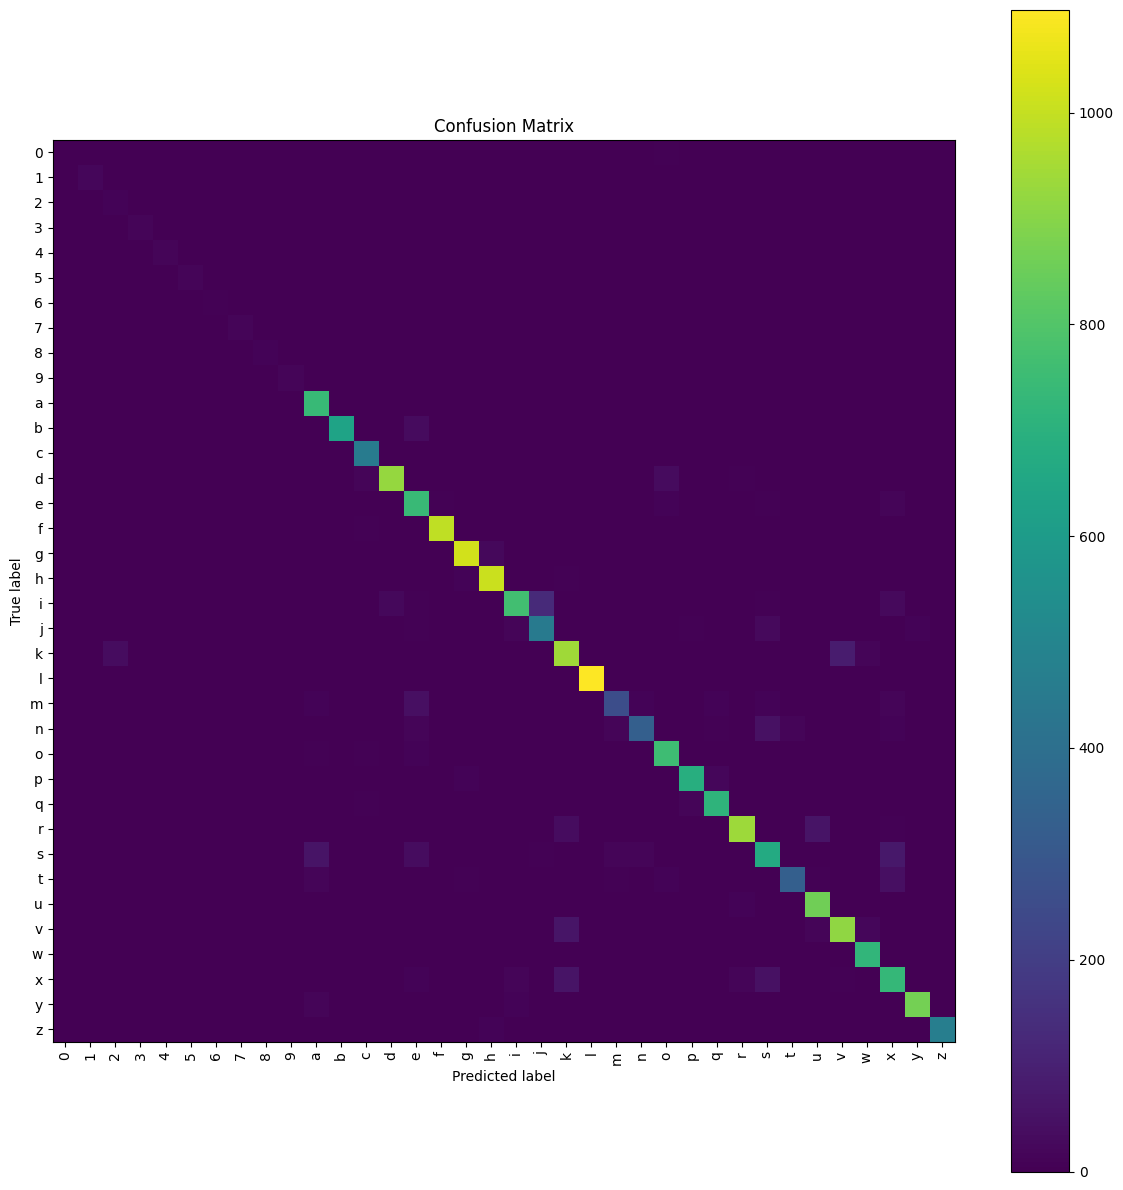

In [39]:
val_data.reset()
y_true = []
y_pred = []
steps = len(val_data)

for _ in range(steps):
    x_batch, y_batch = next(val_data)

    proba = best_model_2_2.predict(x_batch, verbose=0)
    pred = np.argmax(proba, axis=1)
    y_pred.extend(pred.tolist())

    if y_batch.ndim == 2:
        true = np.argmax(y_batch, axis=1)
    else:
        true = y_batch.astype(int)

    y_true.extend(true.tolist())

idx_to_class = {v: k for k, v in val_data.class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(12, 12))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=90)
plt.yticks(ticks, class_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('png/confusion_matrix_2_2.png', dpi=200)
plt.show()

In [40]:
TEST_PATH = 'data/dataset_split/test'
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input)

test_data = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=False
)

Found 650 images belonging to 36 classes.


In [41]:
test_loss, test_acc = best_model_2_2.evaluate(test_data, verbose=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step - accuracy: 0.9215 - loss: 0.9852


In [42]:
test_data.reset()
proba = best_model_2_2.predict(test_data, verbose=0)
y_pred = np.argmax(proba, axis=1)
y_true = test_data.classes

macro_f1 = f1_score(y_true, y_pred, average="macro")
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"TEST macro F1: {macro_f1:.4f}")
print(f"TEST balanced accuracy: {bal_acc:.4f}")

TEST macro F1: 0.9228
TEST balanced accuracy: 0.9213


In [43]:
idx_to_class = {v: k for k, v in test_data.class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.89      1.00      0.94        17
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        14
           4       1.00      0.86      0.92        14
           5       0.88      1.00      0.93        14
           6       1.00      0.73      0.84        11
           7       0.93      1.00      0.97        14
           8       1.00      0.83      0.91        12
           9       1.00      1.00      1.00        14
           a       0.80      1.00      0.89        20
           b       0.95      1.00      0.98        20
           c       1.00      0.85      0.92        20
           d       0.90      0.90      0.90        20
           e       0.83      0.95      0.88        20
           f       1.00      0.90      0.95        20
           g       0.95      1.00      0.98        20
           h       0.95    

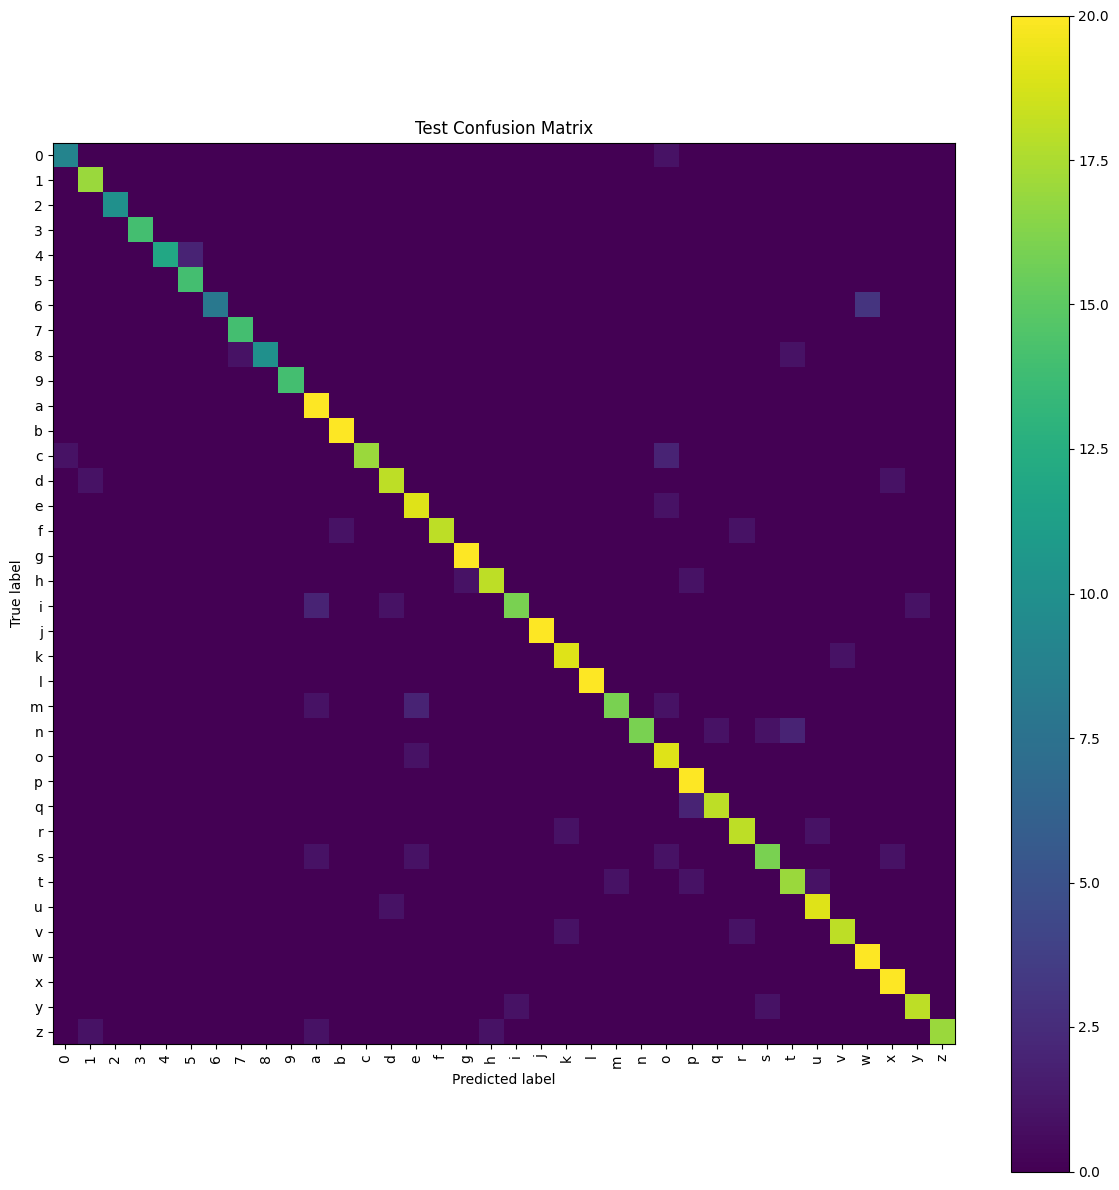

In [44]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

plt.figure(figsize=(12, 12))
plt.imshow(cm, interpolation="nearest")
plt.title("Test Confusion Matrix")
plt.colorbar()
ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=90)
plt.yticks(ticks, class_names)
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("png/test_confusion_matrix_2_2.png", dpi=200)
plt.show()

In [45]:
digit_ids = [test_data.class_indices[str(d)] for d in range(10)]
mask = np.isin(y_true, digit_ids)

digits_macro_f1 = f1_score(np.array(y_true)[mask], np.array(y_pred)[mask], average="macro")
digits_bal_acc  = balanced_accuracy_score(np.array(y_true)[mask], np.array(y_pred)[mask])

print(f"Numbers macro F1: {digits_macro_f1:.4f}")
print(f"Numbers balanced accuracy: {digits_bal_acc:.4f}")

Numbers macro F1: 0.7323
Numbers balanced accuracy: 0.9318


C:\Users\Admin\PycharmProjects\ASL-recognition\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


)))